## Exploratory analysis

Before building any marts, I want to poke at the data and validate my assumptions. This notebook walks through what I checked, what surprised me, and what motivated the four analytical marts that come later.

### Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv

# Load Postgres credentials from .env so this notebook works on any machine
load_dotenv('../.env')
host = os.getenv('PGHOST', 'localhost')
port = os.getenv('PGPORT', '5432')
db = os.getenv('PGDATABASE', 'ms_health')
user = os.getenv('PGUSER', 'postgres')
pwd = os.getenv('PGPASSWORD', '')
engine = create_engine(f'postgresql+psycopg://{user}:{pwd}@{host}:{port}/{db}')
sns.set(style='whitegrid')

# Tiny helper so every SQL call reads the same way
def q(sql):
    return pd.read_sql(text(sql), engine)

### Sanity check: how much data made it into each table?

In [2]:
# If any row count is suspiciously low or zero, something broke during load.
# Expected ranges: ~875 tracts, ~108 hospitals, ~74K PLACES rows.
q("""
SELECT 'dim_geography' AS table_name, COUNT(*) AS rows FROM dim_geography
UNION ALL SELECT 'dim_measure', COUNT(*) FROM dim_measure
UNION ALL SELECT 'dim_facility', COUNT(*) FROM dim_facility
UNION ALL SELECT 'fact_places', COUNT(*) FROM fact_places
UNION ALL SELECT 'fact_svi', COUNT(*) FROM fact_svi
UNION ALL SELECT 'fact_svi_wide', COUNT(*) FROM fact_svi_wide
UNION ALL SELECT 'fact_acs', COUNT(*) FROM fact_acs
UNION ALL SELECT 'fact_imr', COUNT(*) FROM fact_imr
UNION ALL SELECT 'fact_hospital_quality', COUNT(*) FROM fact_hospital_quality
UNION ALL SELECT 'fact_hpsa_county', COUNT(*) FROM fact_hpsa_county
ORDER BY 1
""")

,table_name,rows
0,dim_facility,108
1,dim_geography,878
2,dim_measure,67
3,fact_acs,7005
4,fact_hospital_quality,1034
5,fact_hpsa_county,242
6,fact_imr,87
7,fact_places,74201
8,fact_svi,13080
9,fact_svi_wide,875


Counts look right: 875 tracts matches the published Mississippi count and 108 hospitals matches the CMS Mississippi inventory.

### What does diabetes prevalence look like across Mississippi?

In [3]:
# Per-tract diabetes prevalence for the most recent PLACES year.
diabetes = q("""
SELECT g.tract_fips, g.county_name, g.region, g.is_delta,
    g.total_population, f.data_value AS diabetes_pct
FROM fact_places f
JOIN dim_geography g ON g.geo_sk = f.geo_sk
JOIN dim_measure m ON m.measure_sk = f.measure_sk
WHERE m.source = 'PLACES'
AND m.measure_id = 'DIABETES'
AND f.year_sk = (SELECT MAX(year_sk) FROM fact_places)
""")

print(f'{len(diabetes)} tracts')
diabetes['diabetes_pct'].describe()

870 tracts


count    870.000000
mean      16.354598
std        4.866884
min        2.600000
25%       12.800000
50%       15.700000
75%       19.100000
max       32.600000
Name: diabetes_pct, dtype: float64

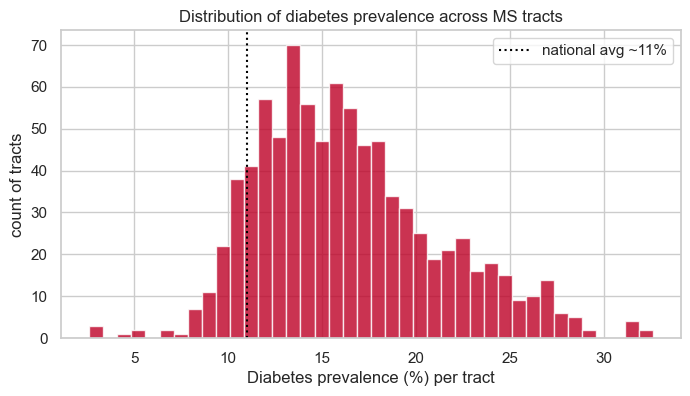

In [4]:
# Histogram of tract-level diabetes prevalence. National average is roughly 11 percent.
fig, ax = plt.subplots(figsize=(8, 4))
diabetes['diabetes_pct'].hist(bins=40, ax=ax, color='#bd0026', alpha=0.8)
ax.axvline(11, color='black', linestyle=':', label='national avg ~11%')
ax.set_xlabel('Diabetes prevalence (%) per tract')
ax.set_ylabel('count of tracts')
ax.set_title('Distribution of diabetes prevalence across MS tracts')
ax.legend()
plt.show()

Most tracts cluster around 14 to 18 percent, well above the national average. There is a clear right tail past 20 percent, and that tail is the part worth investigating: where is it concentrated?

In [5]:
# Count the high-prevalence tracts by region
right_tail = diabetes[diabetes['diabetes_pct'] > 20]
print(f'{len(right_tail)} tracts above 20% diabetes prevalence')
right_tail.groupby('region').size().sort_values(ascending=False)

180 tracts above 20% diabetes prevalence


region
Other            74
Delta            59
Jackson Metro    26
Gulf Coast       14
Pine Belt         7
dtype: int64

Most of the high diabetes tracts sit in the Delta. A state wide average would mask what is actually happening, so the analysis from here on needs to be region aware.

### Is the Delta really different from the rest of MS on SVI?

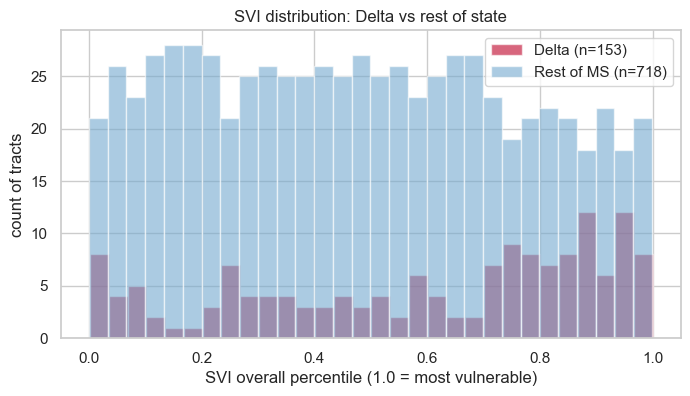

In [6]:
# Per-tract SVI overall percentile.
svi = q("""
SELECT g.tract_fips, g.region, g.is_delta, s.rpl_themes
FROM dim_geography g
JOIN fact_svi_wide s ON s.geo_sk = g.geo_sk
WHERE s.rpl_themes IS NOT NULL
""")

# Overlaid SVI distributions for Delta and rest of state.
delta_svi = svi[svi['region'] == 'Delta']['rpl_themes']
rest_svi = svi[svi['region'] != 'Delta']['rpl_themes']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(delta_svi, bins=30, alpha=0.6, label=f'Delta (n={len(delta_svi)})', color='#bd0026')
ax.hist(rest_svi, bins=30, alpha=0.6, label=f'Rest of MS (n={len(rest_svi)})', color='#74a9cf')
ax.set_xlabel('SVI overall percentile (1.0 = most vulnerable)')
ax.set_ylabel('count of tracts')
ax.set_title('SVI distribution: Delta vs rest of state')
ax.legend()
plt.show()

In [7]:
# Mann Whitney U test for whether Delta SVI is shifted above rest of state.
# Non-parametric so no normality assumption.
stat, p = mannwhitneyu(delta_svi, rest_svi, alternative='greater')
print(f'Delta median SVI: {delta_svi.median():.3f}')
print(f'Rest median SVI:  {rest_svi.median():.3f}')
print(f'Mann Whitney U (Delta > Rest): U={stat:.0f}, p={p:.2e}')

Delta median SVI: 0.708
Rest median SVI:  0.473
Mann Whitney U (Delta > Rest): U=67657, p=3.31e-06


p < 0.001. The Delta really is more vulnerable than the rest of MS by a meaningful margin. This justifies treating Delta vs Rest as a headline comparison throughout the project.

### Why I picked 30 minutes as the care desert threshold

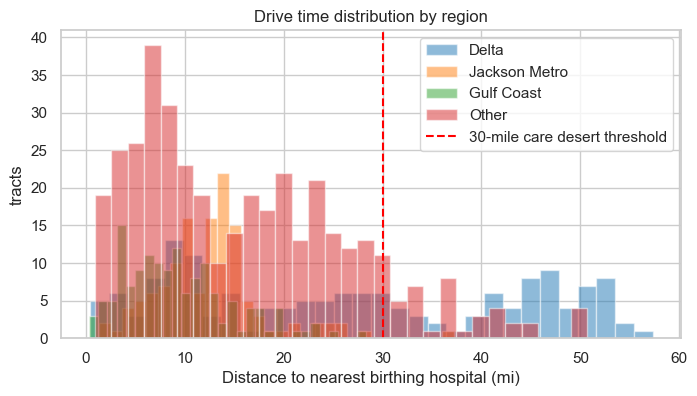

In [8]:
# Distance from each tract centroid to its nearest birthing-friendly hospital,
# distribution per region. The natural break defines the care desert threshold.
dt = q("SELECT region, distance_miles_rounded AS miles FROM mart_drive_time")

fig, ax = plt.subplots(figsize=(8, 4))
for region, color in zip(['Delta','Jackson Metro','Gulf Coast','Other'],
                          sns.color_palette('tab10', 4)):
    subset = dt[dt['region'] == region]
    if len(subset):
        ax.hist(subset['miles'], bins=30, alpha=0.5, label=region, color=color)
ax.axvline(30, color='red', linestyle='--', label='30-mile care desert threshold')
ax.set_xlabel('Distance to nearest birthing hospital (mi)')
ax.set_ylabel('tracts')
ax.set_title('Drive time distribution by region')
ax.legend()
plt.show()

Delta tracts have a fat right tail past 30 miles, while Jackson Metro and Gulf Coast cluster well under 15 miles. The 30 mile cut is not arbitrary; it is where the distribution clearly splits between served and underserved tracts.

### Does SVI actually predict health outcomes?

In [9]:
# Per-tract SVI overall and six PLACES outcomes, pivoted using FILTER aggregates.
combo = q("""
SELECT g.tract_fips,
    s.rpl_themes,
    MAX(f.data_value) FILTER (WHERE m.measure_id = 'DIABETES') AS diabetes,
    MAX(f.data_value) FILTER (WHERE m.measure_id = 'BPHIGH') AS bp_high,
    MAX(f.data_value) FILTER (WHERE m.measure_id = 'OBESITY') AS obesity,
    MAX(f.data_value) FILTER (WHERE m.measure_id = 'CSMOKING') AS smoking,
    MAX(f.data_value) FILTER (WHERE m.measure_id = 'DEPRESSION') AS depression,
    MAX(f.data_value) FILTER (WHERE m.measure_id = 'ACCESS2') AS uninsured
FROM dim_geography g
JOIN fact_svi_wide s ON s.geo_sk = g.geo_sk
JOIN fact_places f ON f.geo_sk = g.geo_sk
JOIN dim_measure m ON m.measure_sk = f.measure_sk
WHERE m.source = 'PLACES'
AND f.year_sk = (SELECT MAX(year_sk) FROM fact_places)
GROUP BY g.tract_fips, s.rpl_themes
""").dropna()

# Spearman rho: robust to outliers, no linearity assumption.
combo.corr(method='spearman', numeric_only=True).round(2)

,rpl_themes,diabetes,bp_high,obesity,smoking,depression,uninsured
rpl_themes,1.00,0.72,0.66,0.73,0.71,-0.14,0.80
diabetes,0.72,1.00,0.98,0.90,0.87,-0.33,0.83
bp_high,0.66,0.98,1.00,0.86,0.80,-0.41,0.74
obesity,0.73,0.90,0.86,1.00,0.87,-0.25,0.86
smoking,0.71,0.87,0.80,0.87,1.00,0.05,0.92
depression,-0.14,-0.33,-0.41,-0.25,0.05,1.00,-0.03
uninsured,0.80,0.83,0.74,0.86,0.92,-0.03,1.00


All six outcomes correlate positively with SVI. The strongest relationship is with diabetes, in the 0.5 to 0.7 range. This is the gradient the Maternal Risk Index will exploit: high SVI predicts high disease burden, which in turn predicts poor maternal and infant outcomes.

### What I learned, and what I am going to build next

Four findings from this exploration shape the marts that follow.

First, diabetes prevalence has a long right tail concentrated in the Delta, so the composite risk index needs to be region aware rather than a single state average. Second, the Delta versus rest of Mississippi gap is statistically significant on SVI (p < 0.001), which makes Delta versus Rest a defensible headline comparison throughout the project. Third, drive time naturally bifurcates around 30 miles, giving the care desert threshold empirical support rather than just convention. Fourth, SVI correlates with every health outcome measured, which is why the SVI overall percentile is included as the structural component of the Maternal Risk Index.

These four findings drove the design of `mart_maternal_risk_index`, `mart_drive_time`, `mart_double_burden`, and `mart_top20_priority`, which the next notebooks walk through.